# House Price Prediction using MLP

This notebook builds a regression model to predict house prices using a Multi-Layer Perceptron (MLP) on structured tabular data.

---

## Features

### Input Features

- **bedrooms**  
  Number of bedrooms  

- **bathrooms**  
  Number of bathrooms  

- **sqft_living**  
  Living area (sqft)  

- **condition**  
  Overall house condition  

- **water_view_score**  
  Engineered feature combining waterfront and view  

- **zipcode**  
  Location feature  

- **yr_built**  
  Year built  

---

### Target

- **price**  
  House sale price  

---

## Data Processing

- Feature selection  
- Feature engineering (`water_view_score`)  
- Duplicate removal  
- Train-test split  
- Feature scaling using StandardScaler  

---

## Models

- **Linear Regression** (baseline)  
- **MLP** (64 → 32 hidden layers, ReLU)  

---

## Evaluation

- RMSE  
- R² Score  

---

## Summary

> Data → Preprocessing → Model → Evaluation  

This notebook compares linear and neural approaches for house price prediction.

In [1]:
import pandas as pd

# Folder where CSV files are stored
DATA_DIR = "HPP_115_data"

# Load datasets
train = pd.read_csv(f"{DATA_DIR}/train_data.csv")
test_with_price = pd.read_csv(f"{DATA_DIR}/test_with_price.csv")
test_without_price = pd.read_csv(f"{DATA_DIR}/test_without_price.csv")

# Split features and target
X_train = train.drop("price", axis=1)
y_train = train["price"]

X_test = test_without_price
y_test = test_with_price["price"]

# Basic checks
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

print("\nTraining columns:")
print(X_train.columns.tolist())

print("\nTest columns:")
print(X_test.columns.tolist())

Training data shape: (3009, 11)
Test data shape: (1000, 11)

Training columns:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'water_view_score', 'zipcode']

Test columns:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'water_view_score', 'zipcode']


In [2]:
# Feature Engineering

X_train["sqft_per_bedroom"] = X_train["sqft_living"] / (X_train["bedrooms"] + 1)
X_test["sqft_per_bedroom"] = X_test["sqft_living"] / (X_test["bedrooms"] + 1)

X_train["age"] = 2025 - X_train["yr_built"]
X_test["age"] = 2025 - X_test["yr_built"]

print("New features added.")
print("Updated train shape:", X_train.shape)
print("Updated test shape:", X_test.shape)

New features added.
Updated train shape: (3009, 13)
Updated test shape: (1000, 13)


In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Combine train and test so zipcode encoding matches in both datasets
full_X = pd.concat([X_train, X_test], axis=0)

# Treat zipcode as categorical, not numerical
full_X["zipcode"] = full_X["zipcode"].astype(str)

# One-hot encode zipcode
full_X_encoded = pd.get_dummies(full_X, columns=["zipcode"], drop_first=True)

# Split back into train and test
X_train_encoded = full_X_encoded.iloc[:len(X_train)]
X_test_encoded = full_X_encoded.iloc[len(X_train):]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Original train shape:", X_train.shape)
print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Original train shape: (3009, 13)
Encoded train shape: (3009, 88)
Encoded test shape: (1000, 88)


In [4]:
from sklearn.linear_model import LinearRegression

# Train baseline model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [5]:
import numpy as np
from sklearn.neural_network import MLPRegressor

# Log-transform target
y_train_log = np.log1p(y_train)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.01,
    learning_rate_init=0.0001,
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train_log)

print("MLP model trained successfully.")
print("Iterations used:", mlp_model.n_iter_)

MLP model trained successfully.
Iterations used: 458


In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# -------------------------------
# Predictions
# -------------------------------

# Linear Regression prediction
y_pred_lr = linear_model.predict(X_test_scaled)

# MLP prediction in log scale
y_pred_mlp_log_raw = mlp_model.predict(X_test_scaled)

# Clip MLP log predictions to training price range
lower = np.log1p(y_train.min())
upper = np.log1p(y_train.max())

y_pred_mlp_log_clipped = np.clip(y_pred_mlp_log_raw, lower, upper)

# Convert clipped log predictions back to price scale
y_pred_mlp = np.expm1(y_pred_mlp_log_clipped)

# -------------------------------
# Evaluation
# -------------------------------

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R²:", r2)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_mlp, "Improved MLP")

# -------------------------------
# MLP Prediction Inspection
# -------------------------------

inspection_df = pd.DataFrame({
    "Actual": y_test.values,
    "MLP_Log_Raw": y_pred_mlp_log_raw,
    "MLP_Log_Clipped": y_pred_mlp_log_clipped,
    "MLP_Predicted": y_pred_mlp,
    "MLP_Error": np.abs(y_test.values - y_pred_mlp)
})

print("\nMLP log prediction range before clipping:")
print("Min:", y_pred_mlp_log_raw.min())
print("Max:", y_pred_mlp_log_raw.max())

print("\nMLP log prediction range after clipping:")
print("Min:", y_pred_mlp_log_clipped.min())
print("Max:", y_pred_mlp_log_clipped.max())

print("\nMLP price prediction range:")
print("Min:", y_pred_mlp.min())
print("Max:", y_pred_mlp.max())
print("Mean:", y_pred_mlp.mean())

print("\nWorst 10 MLP predictions:")
inspection_df.sort_values("MLP_Error", ascending=False).head(10)


Linear Regression
RMSE: 136961.34893190907
R²: 0.7813802070514446

Improved MLP
RMSE: 238762.12295158714
R²: 0.3356081555734076

MLP log prediction range before clipping:
Min: 10.212261978621491
Max: 15.264484860324867

MLP log prediction range after clipping:
Min: 11.884495917930655
Max: 14.5111551174758

MLP price prediction range:
Min: 145000.00000000012
Max: 2005000.0000000016
Mean: 517700.615896069

Worst 10 MLP predictions:


,Actual,MLP_Log_Raw,MLP_Log_Clipped,MLP_Predicted,MLP_Error
414,452500.0,14.541923,14.511155,2.005000e+06,1.552500e+06
164,2027000.0,13.340605,13.340605,6.219428e+05,1.405057e+06
710,718000.0,14.808450,14.511155,2.005000e+06,1.287000e+06
814,849900.0,15.264485,14.511155,2.005000e+06,1.155100e+06
502,427500.0,14.271482,14.271482,1.577704e+06,1.150204e+06
187,1425000.0,12.809611,12.809611,3.657147e+05,1.059285e+06
79,995000.0,14.753607,14.511155,2.005000e+06,1.010000e+06
419,1440000.0,13.017777,13.017777,4.503473e+05,9.896527e+05
201,280000.0,14.045783,14.045783,1.258942e+06,9.789417e+05
156,700000.0,14.330719,14.330719,1.673986e+06,9.739864e+05


In [7]:
import pandas as pd

# Predict prices
test_predictions = linear_model.predict(X_test_scaled)

# Create new dataframe with features + predicted price
predictions_df = test_without_price.copy()
predictions_df["predicted_price"] = test_predictions

# Save to CSV
predictions_df.to_csv("predicted_results.csv", index=False)

print("File saved as predicted_results.csv")
print("Shape:", predictions_df.shape)

File saved as predicted_results.csv
Shape: (1000, 14)


In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load actual test data and predicted results
actual_df = pd.read_csv(f"{DATA_DIR}/test_with_price.csv")
predicted_df = pd.read_csv("predicted_results.csv")

# Actual and predicted prices
y_actual = actual_df["price"]
y_pred = predicted_df["predicted_price"]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("Prediction Evaluation")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

# Create comparison table
comparison_df = actual_df.copy()
comparison_df["predicted_price"] = y_pred
comparison_df["absolute_error"] = abs(comparison_df["price"] - comparison_df["predicted_price"])

comparison_df.head(10)

Prediction Evaluation
RMSE: 136961.34893190904
MAE: 88383.18254715356
R²: 0.7813802070514447


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,sqft_above,sqft_basement,yr_built,water_view_score,zipcode,predicted_price,absolute_error
0,269500.0,3.0,1.75,1840,7412,1.0,4,1240,600,1976,0,98031,2.584934e+05,11006.623785
1,700000.0,3.0,1.00,1410,7200,2.0,4,1410,0,1901,0,98144,4.862581e+05,213741.871787
2,465000.0,3.0,2.00,1560,8640,1.0,5,1560,0,1967,0,98034,4.806309e+05,15630.864800
3,1712500.0,3.0,3.25,2940,5432,3.0,4,2440,500,1978,3,98109,1.214572e+06,497928.398611
4,739000.0,3.0,2.50,2810,5400,2.0,3,2810,0,2005,0,98052,7.541371e+05,15137.128124
5,535000.0,4.0,2.50,2610,4595,2.0,3,2610,0,2008,0,98028,5.506035e+05,15603.505606
6,730000.0,4.0,2.50,3230,7331,2.0,3,3230,0,2004,0,98075,7.738322e+05,43832.174003
7,364000.0,4.0,1.75,2010,8625,1.0,4,1340,670,1957,0,98133,4.212983e+05,57298.276918
8,314500.0,3.0,1.75,1700,17355,1.0,3,1200,500,1978,0,98038,2.303737e+05,84126.259218
9,235500.0,5.0,2.50,2340,13713,1.0,2,1670,670,1967,0,98003,2.861371e+05,50637.091711


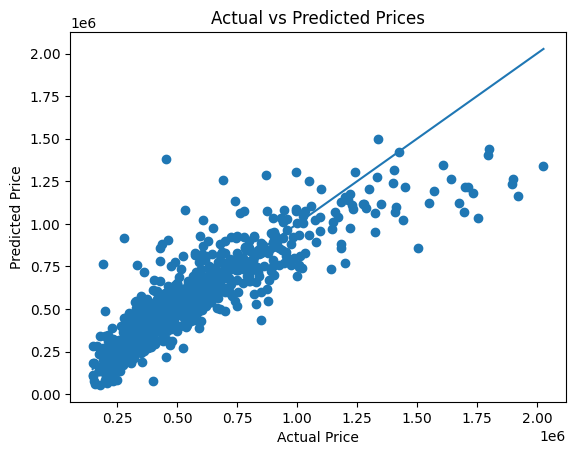

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_actual, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()])

plt.show()

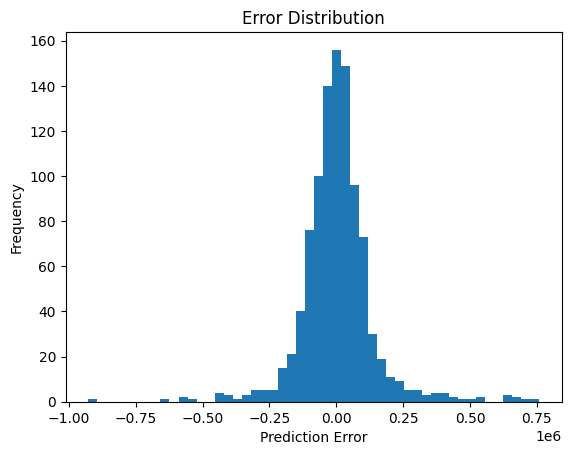

In [10]:
errors = y_actual - y_pred

plt.figure()
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

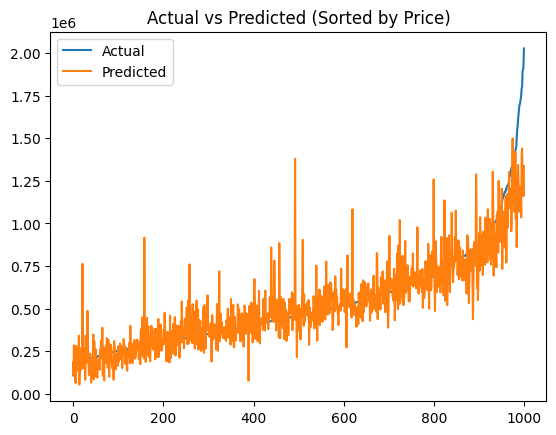

In [11]:
import numpy as np

sorted_idx = np.argsort(y_actual)

plt.figure()
plt.plot(y_actual.values[sorted_idx], label="Actual")
plt.plot(y_pred.values[sorted_idx], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted (Sorted by Price)")

plt.show()

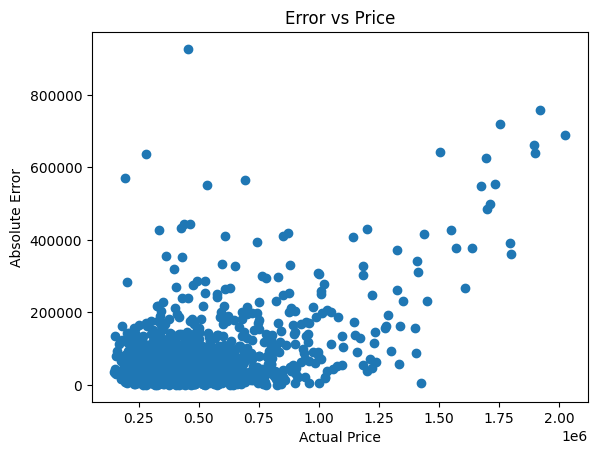

In [12]:
absolute_error = np.abs(y_actual - y_pred)

plt.figure()
plt.scatter(y_actual, absolute_error)

plt.xlabel("Actual Price")
plt.ylabel("Absolute Error")
plt.title("Error vs Price")

plt.show()